##Disciplina: 2026.1 - Modelos Descritivos - CESAR School
## Análise NBA 2024/2025
**Alunos** :<br>
Gabriel Rocha Franceschini<br>
Breno Mota Ferreira Lima<br>
Vinicius Magalhães de Souza Sena<br>
Renan Victor Cavalcanti Penna

**Problemática**: <br> Identificar os melhores jogadores de 2024/2025 com potencial de valorização de mercado, a fim de comercializar as análises estatísticas

# Importação de Libs


In [ ]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Importando Kaggle e Carregando Dataset

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("eduardopalmieri/nba-player-stats-season-2425")


Using Colab cache for faster access to the 'nba-player-stats-season-2425' dataset.


In [ ]:
df = pd.read_csv(os.path.join(path, "database_24_25.csv"))


# Descrição do DataSet


| Nome       | Descrição                                        | Tipo do Dado                 |
| ---------- | ------------------------------------------------ | ---------------------------- |
| **Player** | Nome do jogador                                  | `string`                     |
| **Tm**     | Sigla do time do jogador                         | `string`                     |
| **Opp**    | Sigla do time adversário                         | `string`                     |
| **Res**    | Resultado do jogo (Win/Loss)                     | `string`                     |
| **MP**     | Minutos jogados (ex: 23.5 = 23min30s)            | `float64`                    |
| **FG**     | Cestas de quadra convertidas                     | `int64`                      |
| **FGA**    | Tentativas de arremessos de quadra               | `int64`                      |
| **FG%**    | Percentual de acerto nos arremessos de quadra    | `float64`                    |
| **3P**     | Cestas de 3 pontos convertidas                   | `int64`                      |
| **3PA**    | Tentativas de 3 pontos                           | `int64`                      |
| **3P%**    | Percentual de acerto de 3 pontos                 | `float64`                    |
| **FT**     | Lances livres convertidos                        | `int64`                      |
| **FTA**    | Tentativas de lances livres                      | `int64`                      |
| **FT%**    | Percentual de acerto de lances livres            | `float64`                    |
| **ORB**    | Rebotes ofensivos                                | `int64`                      |
| **DRB**    | Rebotes defensivos                               | `int64`                      |
| **TRB**    | Total de rebotes                                 | `int64`                      |
| **AST**    | Assistências                                     | `int64`                      |
| **STL**    | Roubos de bola                                   | `int64`                      |
| **BLK**    | Tocos (bloqueios)                                | `int64`                      |
| **TOV**    | Turnovers (perdas de bola)                       | `int64`                      |
| **PF**     | Faltas pessoais                                  | `int64`                      |
| **PTS**    | Pontos totais no jogo                            | `int64`                      |
| **GmSc**   | Game Score (métrica de desempenho geral no jogo) | `float64`                    |
| **Date**   | Data do jogo (formato YYYY-MM-DD)                | `datetime64`   |


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  16512 non-null  object 
 1   Tm      16512 non-null  object 
 2   Opp     16512 non-null  object 
 3   Res     16512 non-null  object 
 4   MP      16512 non-null  float64
 5   FG      16512 non-null  int64  
 6   FGA     16512 non-null  int64  
 7   FG%     16512 non-null  float64
 8   3P      16512 non-null  int64  
 9   3PA     16512 non-null  int64  
 10  3P%     16512 non-null  float64
 11  FT      16512 non-null  int64  
 12  FTA     16512 non-null  int64  
 13  FT%     16512 non-null  float64
 14  ORB     16512 non-null  int64  
 15  DRB     16512 non-null  int64  
 16  TRB     16512 non-null  int64  
 17  AST     16512 non-null  int64  
 18  STL     16512 non-null  int64  
 19  BLK     16512 non-null  int64  
 20  TOV     16512 non-null  int64  
 21  PF      16512 non-null  int64  
 22

In [ ]:
#DIMENSÕES E ESTRUTURA
df.shape


(16512, 25)

# Estatísticas Descritivas

In [ ]:
desc = df.describe().T.round(2)
desc

,count,mean,std,min,25%,50%,75%,max
MP,16512.0,22.41,10.90,0.0,14.43,23.43,31.32,50.48
FG,16512.0,3.85,3.26,0.0,1.00,3.00,6.00,22.00
FGA,16512.0,8.27,6.07,0.0,4.00,7.00,12.00,38.00
FG%,16512.0,0.43,0.25,0.0,0.29,0.44,0.57,1.00
3P,16512.0,1.25,1.52,0.0,0.00,1.00,2.00,10.00
3PA,16512.0,3.48,3.15,0.0,1.00,3.00,5.00,20.00
3P%,16512.0,0.26,0.29,0.0,0.00,0.25,0.50,1.00
FT,16512.0,1.57,2.23,0.0,0.00,1.00,2.00,18.00
FTA,16512.0,2.02,2.69,0.0,0.00,1.00,3.00,26.00
FT%,16512.0,0.42,0.44,0.0,0.00,0.33,1.00,1.00


In [ ]:
duplicatas = df.duplicated().sum()
total = len(df)

print(f"Total de registros: {total}")
print(f"Total de duplicatas: {duplicatas}")

if duplicatas > 0:
    print("\n🔍 Exemplos de duplicatas:")
    print(df[df.duplicated(keep=False)].head())

Total de registros: 16512
Total de duplicatas: 0


In [ ]:
#Números Nulos
df.isnull().sum()

,0
Player,0
Tm,0
Opp,0
Res,0
MP,0
FG,0
FGA,0
FG%,0
3P,0
3PA,0


# Análises Jogador

In [ ]:
# DF filtrado com jogadores com minutagem razoavel
df_scout = df.groupby(['Player', 'Tm']).agg(
    Jogos=('Player', 'count'),
    Minutos_Totais=('MP', 'sum'),
    MPG=('MP', 'mean'),
    PPG=('PTS', 'mean'),
    RPG=('TRB', 'mean'),
    APG=('AST', 'mean'),
    SPG=('STL', 'mean'),
    BPG=('BLK', 'mean'),
    TOV_PG=('TOV', 'mean'),
    FG_Made=('FG', 'sum'),
    FG_Att=('FGA', 'sum'),
    TP_Made=('3P', 'sum'),
    TP_Att=('3PA', 'sum')
).reset_index()

df_scout = df_scout[(df_scout['Jogos'] >= 15) & (df_scout['MPG'] >= 15)].copy()

# Aproveitamento Real
df_scout['eFG%'] = (df_scout['FG_Made'] + 0.5 * df_scout['TP_Made']) / df_scout['FG_Att']

# Relação Assistência / Erro (AST/TO Ratio)
df_scout['AST/TOV'] = df_scout['APG'] / df_scout['TOV_PG'].replace(0, 0.1)

df_scout = df_scout.round(2)

print(df_scout)


                 Player   Tm  Jogos  Minutos_Totais    MPG    PPG   RPG   APG  \
0            A.J. Green  MIL     44          967.89  22.00   7.66  2.25  1.27   
4          Aaron Gordon  DEN     30          799.98  26.67  12.33  4.73  3.07   
6         Aaron Nesmith  IND     15          314.24  20.95   8.20  3.33  1.27   
7         Aaron Wiggins  OKC     51         1087.46  21.32  10.14  3.57  1.57   
11        Ajay Mitchell  OKC     35          576.92  16.48   6.43  1.97  1.69   
..                  ...  ...    ...             ...    ...    ...   ...   ...   
574  Zaccharie Risacher  ATL     45         1070.30  23.78  11.20  3.47  1.18   
576           Zach Edey  MEM     37          772.11  20.87   9.86  7.78  1.00   
577         Zach LaVine  CHI     42         1432.05  34.10  23.98  4.81  4.50   
580     Ziaire Williams  BRK     38          896.61  23.60   9.39  4.79  1.42   
581     Zion Williamson  NOP     15          425.62  28.37  23.27  7.87  4.93   

      SPG   BPG  TOV_PG  FG

In [ ]:
# Média dos melhores pontuadores da temporada
medias_jogadores = df.groupby('Player').agg(
    Jogos=('Player', 'count'),
    Minutos_Media=('MP', 'mean'),
    Pontos_Media=('PTS', 'mean'),
    Assistencias_Media=('AST', 'mean'),
    Rebotes_Media=('TRB', 'mean'),
    Impacto_Medio=('GmSc', 'mean')
).round(2)

jogadores_regulares = medias_jogadores[medias_jogadores['Jogos'] >= 15]

top_pontuadores = jogadores_regulares.sort_values(by='Pontos_Media', ascending=False)

display(top_pontuadores.head(10))

,Jogos,Minutos_Media,Pontos_Media,Assistencias_Media,Rebotes_Media,Impacto_Medio
Player,,,,,,
Shai Gilgeous-Alexander,50,34.07,32.44,5.90,5.22,26.74
Giannis Antetokounmpo,42,34.95,31.62,5.98,12.33,26.38
Nikola Jokić,46,36.23,29.70,10.33,12.70,30.57
Luka Dončić,22,35.66,28.14,7.82,8.32,22.70
LaMelo Ball,32,33.36,28.03,7.38,5.22,18.81
Tyrese Maxey,44,38.03,27.84,6.20,3.43,20.47
Anthony Edwards,51,36.73,27.22,4.53,5.78,18.78
Kevin Durant,39,36.16,26.92,4.18,6.08,20.33
Jaren Jackson Jr.,18,32.11,26.56,2.94,6.39,19.29


In [ ]:
# AGREGAÇÃO POR JOGADOR (SIMPLIFICADA)
df_agg = df.groupby('Player').agg({
    'PTS': 'sum',
    'MP': 'sum',
    'TRB': 'sum',
    'AST': 'sum',
    'STL': 'sum',
    'BLK': 'sum',
    'TOV': 'sum',
    'FG%': 'mean',
    '3P%': 'mean',
    'FT%': 'mean',
    'Tm': 'first'
}).round(2)

df_agg['PTS/MIN'] = (df_agg['PTS'] / df_agg['MP']).round(2)

df_agg = df_agg.sort_values('PTS', ascending=False)

# Top 5 simples por cada métrica
resultado = {
    'PONTOS TOTAIS': df_agg.nlargest(5, 'PTS')[['Tm', 'PTS', 'MP', 'PTS/MIN']],
    'REBOTES': df_agg.nlargest(5, 'TRB')[['Tm', 'TRB', 'MP']],
    'ASSISTÊNCIAS': df_agg.nlargest(5, 'AST')[['Tm', 'AST', 'MP']],
    'ROUBOS': df_agg.nlargest(5, 'STL')[['Tm', 'STL', 'MP']],
    'BLOQUEIOS': df_agg.nlargest(5, 'BLK')[['Tm', 'BLK', 'MP']],
    'TURNOVERS': df_agg.nsmallest(5, 'TOV')[['Tm', 'TOV', 'MP']],  # Menor é melhor
    'ACERTO QUADRA (FG%)': df_agg.nlargest(5, 'FG%')[['Tm', 'FG%', 'MP']],
    'ACERTO 3 PONTOS (3P%)': df_agg.nlargest(5, '3P%')[['Tm', '3P%', 'MP']],
    'ACERTO LANCE LIVRE (FT%)': df_agg.nlargest(5, 'FT%')[['Tm', 'FT%', 'MP']],
}


In [ ]:
df_agg

,PTS,MP,TRB,AST,STL,BLK,TOV,FG%,3P%,FT%,Tm,PTS/MIN
Player,,,,,,,,,,,,
Shai Gilgeous-Alexander,1622,1703.72,261,295,97,50,134,0.53,0.37,0.90,OKC,0.95
Anthony Edwards,1388,1873.16,295,231,58,35,176,0.44,0.41,0.80,MIN,0.74
Nikola Jokić,1366,1666.68,584,475,84,31,142,0.59,0.50,0.80,DEN,0.82
Giannis Antetokounmpo,1328,1467.71,518,251,33,57,145,0.61,0.07,0.54,MIL,0.90
Jalen Brunson,1304,1763.69,145,376,48,4,121,0.49,0.36,0.79,NYK,0.74
...,...,...,...,...,...,...,...,...,...,...,...,...
Justin Minaya,0,17.62,3,2,1,0,0,0.00,0.00,0.00,POR,0.00
Daniss Jenkins,0,8.32,0,0,0,0,1,0.00,0.00,0.00,DET,0.00
Cole Swider,0,13.09,2,1,0,0,0,0.00,0.00,0.00,DET,0.00


In [ ]:
df_agg.columns

Index(['PTS', 'MP', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%',
       'Tm', 'PTS/MIN'],
      dtype='object')

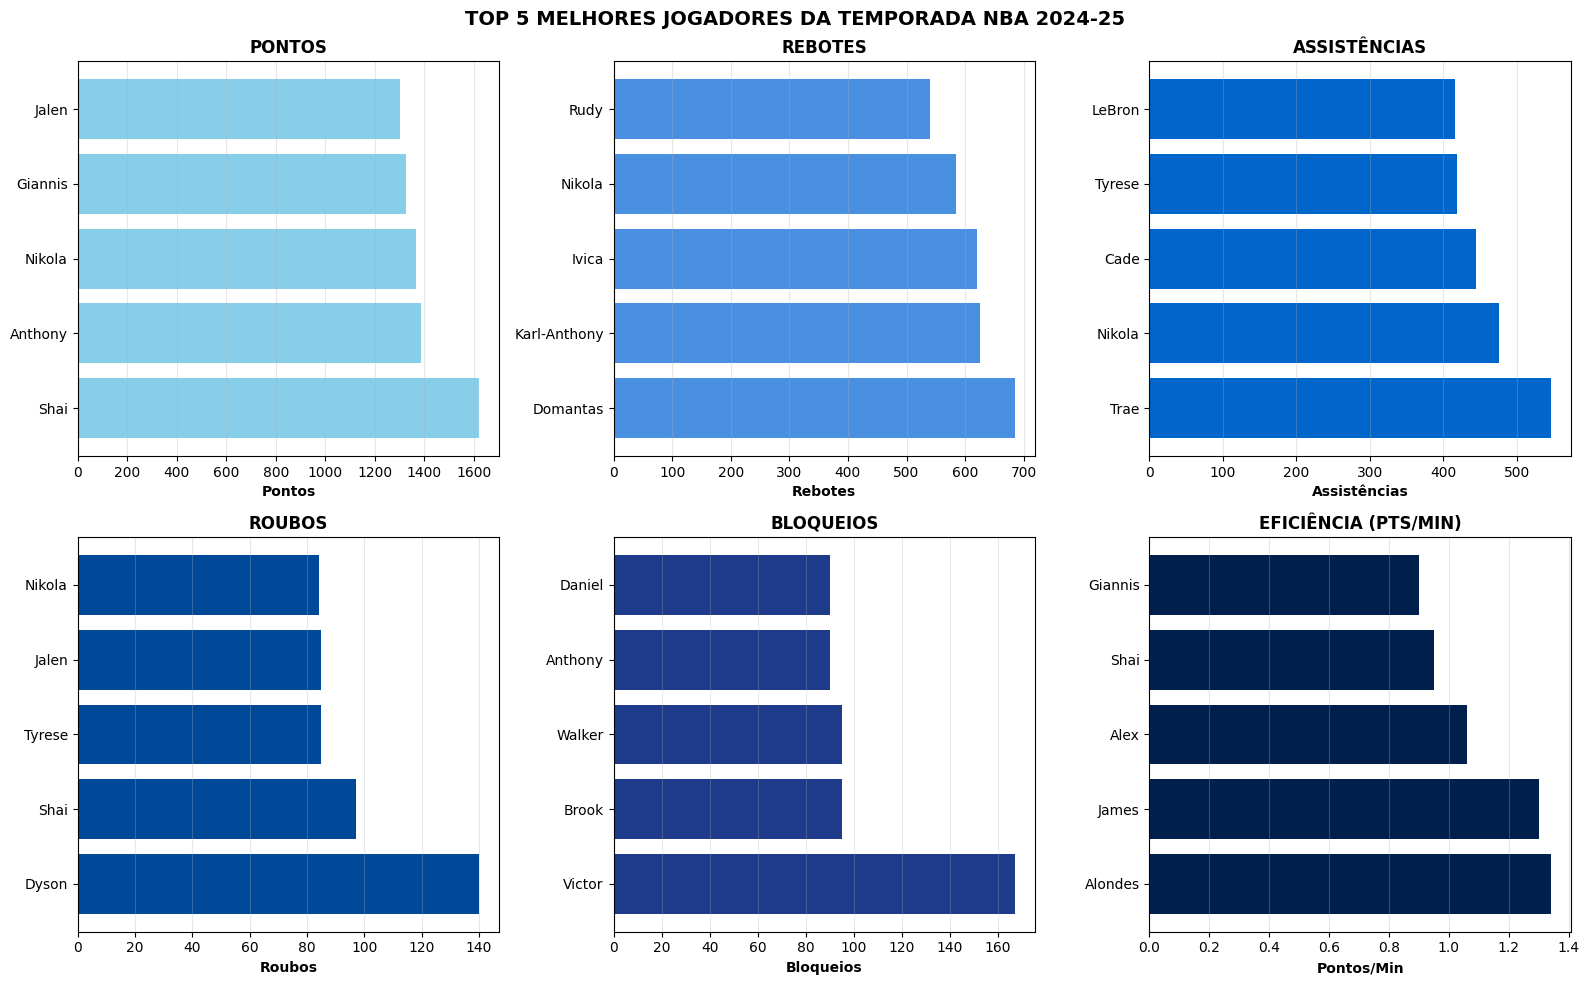

In [ ]:
# Gráficos - Top 5 Jogadores
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('TOP 5 MELHORES JOGADORES DA TEMPORADA NBA 2024-25', fontsize=14, fontweight='bold')

# Paleta de azuis - do claro ao escuro
cores_azul = ['#87CEEB', '#4A90E2', '#0066CC', '#004999', '#1E3A8A', '#001F4D']

# 1. Pontos
ax = axes[0, 0]
top_pts = df_agg.nlargest(5, 'PTS')
ax.barh(range(len(top_pts)), top_pts['PTS'], color=cores_azul[0])
ax.set_yticks(range(len(top_pts)))
ax.set_yticklabels([p.split()[0] for p in top_pts.index], fontsize=10)
ax.set_xlabel('Pontos', fontweight='bold')
ax.set_title('PONTOS', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 2. Rebotes
ax = axes[0, 1]
top_trb = df_agg.nlargest(5, 'TRB')
ax.barh(range(len(top_trb)), top_trb['TRB'], color=cores_azul[1])
ax.set_yticks(range(len(top_trb)))
ax.set_yticklabels([p.split()[0] for p in top_trb.index], fontsize=10)
ax.set_xlabel('Rebotes', fontweight='bold')
ax.set_title('REBOTES', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 3. Assistências
ax = axes[0, 2]
top_ast = df_agg.nlargest(5, 'AST')
ax.barh(range(len(top_ast)), top_ast['AST'], color=cores_azul[2])
ax.set_yticks(range(len(top_ast)))
ax.set_yticklabels([p.split()[0] for p in top_ast.index], fontsize=10)
ax.set_xlabel('Assistências', fontweight='bold')
ax.set_title('ASSISTÊNCIAS', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 4. Roubos
ax = axes[1, 0]
top_stl = df_agg.nlargest(5, 'STL')
ax.barh(range(len(top_stl)), top_stl['STL'], color=cores_azul[3])
ax.set_yticks(range(len(top_stl)))
ax.set_yticklabels([p.split()[0] for p in top_stl.index], fontsize=10)
ax.set_xlabel('Roubos', fontweight='bold')
ax.set_title('ROUBOS', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 5. Bloqueios
ax = axes[1, 1]
top_blk = df_agg.nlargest(5, 'BLK')
ax.barh(range(len(top_blk)), top_blk['BLK'], color=cores_azul[4])
ax.set_yticks(range(len(top_blk)))
ax.set_yticklabels([p.split()[0] for p in top_blk.index], fontsize=10)
ax.set_xlabel('Bloqueios', fontweight='bold')
ax.set_title('BLOQUEIOS', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 6. Pontos por Minuto
ax = axes[1, 2]
top_pts_min = df_agg.nlargest(5, 'PTS/MIN')
ax.barh(range(len(top_pts_min)), top_pts_min['PTS/MIN'], color=cores_azul[5])
ax.set_yticks(range(len(top_pts_min)))
ax.set_yticklabels([p.split()[0] for p in top_pts_min.index], fontsize=10)
ax.set_xlabel('Pontos/Min', fontweight='bold')
ax.set_title('EFICIÊNCIA (PTS/MIN)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Clusterização

In [ ]:
df_scout[df_scout['Player'] == 'LeBron James']

,Player,Tm,Jogos,Minutos_Totais,MPG,PPG,RPG,APG,SPG,BPG,TOV_PG,FG_Made,FG_Att,TP_Made,TP_Att,eFG%,AST/TOV
365,LeBron James,LAL,46,1594.86,34.67,24.46,7.78,9.04,0.87,0.52,3.78,432,838,100,256,0.58,2.39


In [ ]:
df_clusters = df_scout.drop(columns=['Tm','Player'])
df_clusters

,Jogos,Minutos_Totais,MPG,PPG,RPG,APG,SPG,BPG,TOV_PG,FG_Made,FG_Att,TP_Made,TP_Att,eFG%,AST/TOV
0,44,967.89,22.00,7.66,2.25,1.27,0.55,0.11,0.61,114,258,96,222,0.63,2.07
4,30,799.98,26.67,12.33,4.73,3.07,0.47,0.27,1.33,130,255,34,84,0.58,2.30
6,15,314.24,20.95,8.20,3.33,1.27,0.60,0.27,0.73,41,83,15,36,0.58,1.73
7,51,1087.46,21.32,10.14,3.57,1.57,0.73,0.24,0.82,205,414,68,188,0.58,1.90
11,35,576.92,16.48,6.43,1.97,1.69,0.69,0.09,0.80,86,172,22,53,0.56,2.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,45,1070.30,23.78,11.20,3.47,1.18,0.78,0.47,1.11,189,448,58,190,0.49,1.06
576,37,772.11,20.87,9.86,7.78,1.00,0.65,1.19,1.51,150,255,14,39,0.62,0.66
577,42,1432.05,34.10,23.98,4.81,4.50,0.93,0.24,2.88,363,710,136,305,0.61,1.56
580,38,896.61,23.60,9.39,4.79,1.42,1.00,0.42,1.05,120,300,49,151,0.48,1.35


In [ ]:
std_scaler = StandardScaler()
std_df = pd.DataFrame(std_scaler.fit_transform(df_clusters),
                             columns=df_clusters.columns)

In [ ]:
std_df

,Jogos,Minutos_Totais,MPG,PPG,RPG,APG,SPG,BPG,TOV_PG,FG_Made,FG_Att,TP_Made,TP_Att,eFG%,AST/TOV
0,0.572857,-0.071454,-0.622269,-0.760606,-1.029438,-0.848806,-0.945092,-0.948233,-1.063258,-0.578268,-0.540247,0.921000,0.588283,1.589571,0.107846
1,-0.734751,-0.481820,0.120509,-0.020114,0.004548,0.097338,-1.161864,-0.586688,-0.206246,-0.427987,-0.554007,-0.548749,-0.674939,0.685783,0.392165
2,-2.135760,-1.668949,-0.789275,-0.674981,-0.579153,-0.848806,-0.809610,-0.586688,-0.920423,-1.263925,-1.342905,-0.999156,-1.114321,0.685783,-0.312451
3,1.226661,0.220770,-0.730426,-0.367368,-0.479090,-0.691115,-0.457356,-0.654478,-0.813296,0.276454,0.175264,0.257242,0.277055,0.685783,-0.102302
4,-0.267748,-1.026969,-1.500243,-0.955639,-1.146178,-0.628039,-0.565742,-0.993426,-0.837102,-0.841260,-0.934696,-0.833217,-0.958706,0.324268,0.157293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,0.666257,0.178832,-0.339155,-0.199290,-0.520783,-0.896113,-0.321873,-0.134758,-0.468111,0.126173,0.331209,0.020186,0.295362,-0.941035,-1.140685
326,-0.080947,-0.549933,-0.802000,-0.411766,1.276184,-0.990727,-0.674127,1.492194,0.008007,-0.240136,-0.554007,-1.022862,-1.086859,1.408814,-1.635152
327,0.386056,1.062934,1.302275,1.827152,0.037903,0.848997,0.084574,-0.654478,1.638712,1.760478,1.532902,1.869225,1.348047,1.228056,-0.522600
328,0.012453,-0.245660,-0.367784,-0.486291,0.029564,-0.769960,0.274249,-0.247740,-0.539528,-0.521913,-0.347610,-0.193165,-0.061635,-1.121793,-0.782196


In [ ]:
pca = PCA(n_components=2,random_state=42)
pca_df = pd.DataFrame(pca.fit_transform(std_df),columns=['PCA1','PCA2'])
pca_df

,PCA1,PCA2
0,-1.200288,-1.513453
1,-1.232098,0.213817
2,-3.736511,0.368235
3,-0.320802,-0.890613
4,-3.070166,-0.824784
...,...,...
325,-0.289968,-0.505793
326,-1.595716,2.952674
327,4.265724,-0.370895
328,-1.110330,-0.218632


In [ ]:
std_pca_df = pd.concat([std_df,pca_df],axis=1)
pca_values = std_pca_df[['PCA1','PCA2']]
std_pca_df

,Jogos,Minutos_Totais,MPG,PPG,RPG,APG,SPG,BPG,TOV_PG,FG_Made,FG_Att,TP_Made,TP_Att,eFG%,AST/TOV,PCA1,PCA2
0,0.572857,-0.071454,-0.622269,-0.760606,-1.029438,-0.848806,-0.945092,-0.948233,-1.063258,-0.578268,-0.540247,0.921000,0.588283,1.589571,0.107846,-1.200288,-1.513453
1,-0.734751,-0.481820,0.120509,-0.020114,0.004548,0.097338,-1.161864,-0.586688,-0.206246,-0.427987,-0.554007,-0.548749,-0.674939,0.685783,0.392165,-1.232098,0.213817
2,-2.135760,-1.668949,-0.789275,-0.674981,-0.579153,-0.848806,-0.809610,-0.586688,-0.920423,-1.263925,-1.342905,-0.999156,-1.114321,0.685783,-0.312451,-3.736511,0.368235
3,1.226661,0.220770,-0.730426,-0.367368,-0.479090,-0.691115,-0.457356,-0.654478,-0.813296,0.276454,0.175264,0.257242,0.277055,0.685783,-0.102302,-0.320802,-0.890613
4,-0.267748,-1.026969,-1.500243,-0.955639,-1.146178,-0.628039,-0.565742,-0.993426,-0.837102,-0.841260,-0.934696,-0.833217,-0.958706,0.324268,0.157293,-3.070166,-0.824784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,0.666257,0.178832,-0.339155,-0.199290,-0.520783,-0.896113,-0.321873,-0.134758,-0.468111,0.126173,0.331209,0.020186,0.295362,-0.941035,-1.140685,-0.289968,-0.505793
326,-0.080947,-0.549933,-0.802000,-0.411766,1.276184,-0.990727,-0.674127,1.492194,0.008007,-0.240136,-0.554007,-1.022862,-1.086859,1.408814,-1.635152,-1.595716,2.952674
327,0.386056,1.062934,1.302275,1.827152,0.037903,0.848997,0.084574,-0.654478,1.638712,1.760478,1.532902,1.869225,1.348047,1.228056,-0.522600,4.265724,-0.370895
328,0.012453,-0.245660,-0.367784,-0.486291,0.029564,-0.769960,0.274249,-0.247740,-0.539528,-0.521913,-0.347610,-0.193165,-0.061635,-1.121793,-0.782196,-1.110330,-0.218632


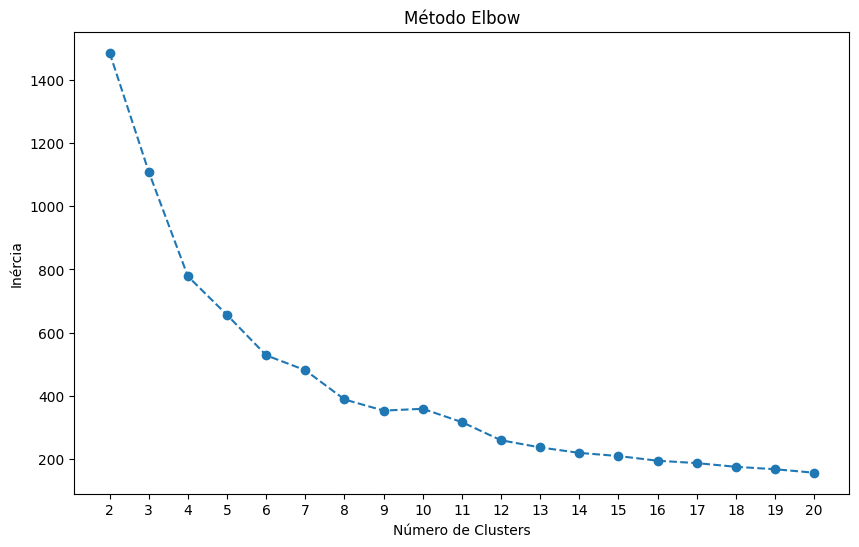

In [ ]:
# Método Elbow
inercia = []
for i in range(2,21):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(pca_values)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(2,21),inercia,marker='o',linestyle='--')
plt.title('Método Elbow')
plt.xticks(range(2,21))
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.show()

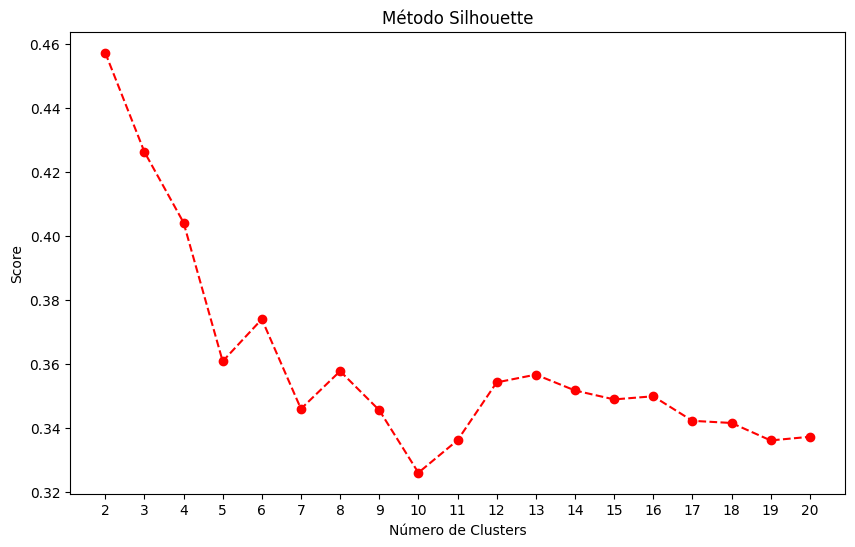

In [ ]:
# Score da Silhueta

silhueta = []
for i in range(2,21):
    kmeans = KMeans(n_clusters=i,random_state=42)
    labels = kmeans.fit_predict(pca_values)
    score = silhouette_score(pca_values,labels)
    silhueta.append(score)

plt.figure(figsize=(10,6))
plt.plot(range(2,21),silhueta,color='r',marker='o',linestyle='--')
plt.xticks(range(2,21))
plt.title('Método Silhouette')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.show()

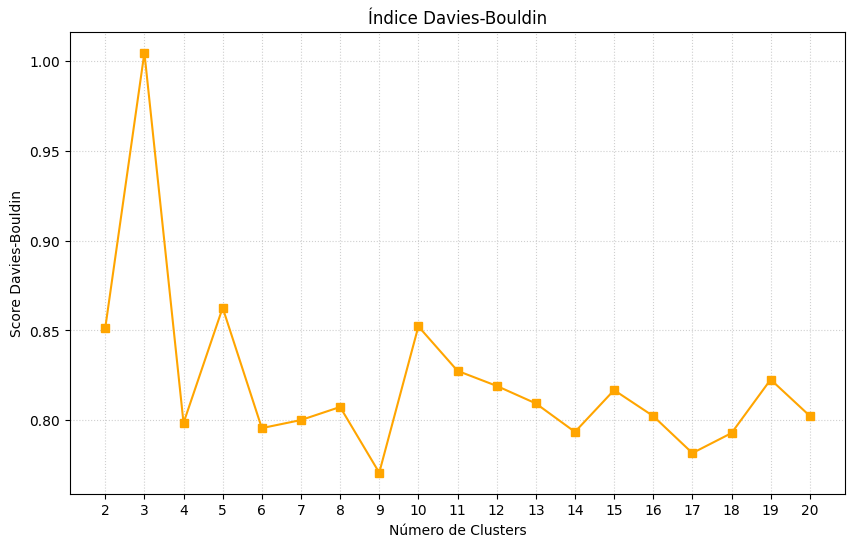

In [ ]:
# Método Davies-Bouldin
davies_bouldin_scores = []

for i in range(2, 21):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    # Fit e predict para pegar os rótulos gerados
    labels = kmeans.fit_predict(pca_values)

    # Calcula o score passando os dados e os rótulos
    score = davies_bouldin_score(pca_values, labels)
    davies_bouldin_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 21), davies_bouldin_scores, marker='s', linestyle='-', color='orange')
plt.title('Índice Davies-Bouldin')
plt.xticks(range(2, 21))
plt.xlabel('Número de Clusters')
plt.ylabel('Score Davies-Bouldin')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

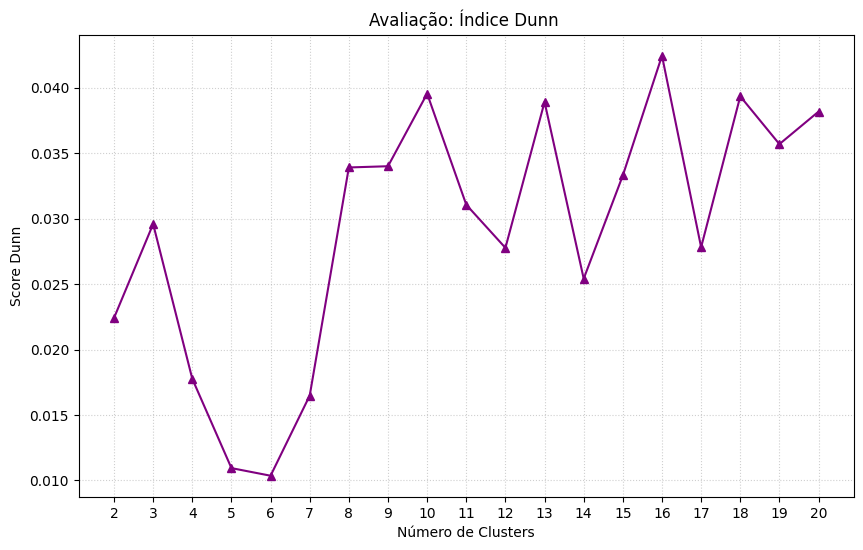

In [ ]:
# Método Dunn
#!pip install validclust
from sklearn.metrics import pairwise_distances
from validclust import dunn
# A função dunn do validclust exige que você passe a matriz de distâncias dos dados
dunn_scores = []

# A função dunn do validclust exige que você passe a matriz de distâncias dos dados
matriz_distancias = pairwise_distances(pca_values)

for i in range(2, 21):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_values)

    # Chama o cálculo do Índice Dunn "normal"
    score = dunn(matriz_distancias, labels)
    dunn_scores.append(score)

# Plotagem do gráfico
plt.figure(figsize=(10, 6))
plt.plot(range(2, 21), dunn_scores, marker='^', linestyle='-', color='purple')
plt.title('Avaliação: Índice Dunn ')
plt.xticks(range(2, 21))
plt.xlabel('Número de Clusters')
plt.ylabel('Score Dunn')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
av_interna = pd.concat([
    pd.DataFrame(range(2, 21), columns=['Número de Clusters']),
    pd.DataFrame(inercia, columns=['Inércia']),
    pd.DataFrame(silhueta, columns=['Score Silhueta']),
    pd.DataFrame(dunn_scores, columns=['Índice Dunn']),
    pd.DataFrame(davies_bouldin_scores, columns=['Índice Davies-Bouldin'])
], axis=1)

display(av_interna)

,Número de Clusters,Inércia,Score Silhueta,Índice Dunn,Índice Davies-Bouldin
0,2,1484.990476,0.457284,0.022410,0.851382
1,3,1108.389455,0.426306,0.029586,1.004461
2,4,778.035390,0.404235,0.017762,0.798518
3,5,656.210300,0.360889,0.010942,0.862600
4,6,528.569856,0.374037,0.010360,0.795654
5,7,481.328286,0.346030,0.016480,0.800133
6,8,388.975777,0.357813,0.033906,0.807405
7,9,353.755961,0.345614,0.033999,0.770833
8,10,359.447548,0.326077,0.039545,0.852227
9,11,317.321348,0.336219,0.031057,0.827498


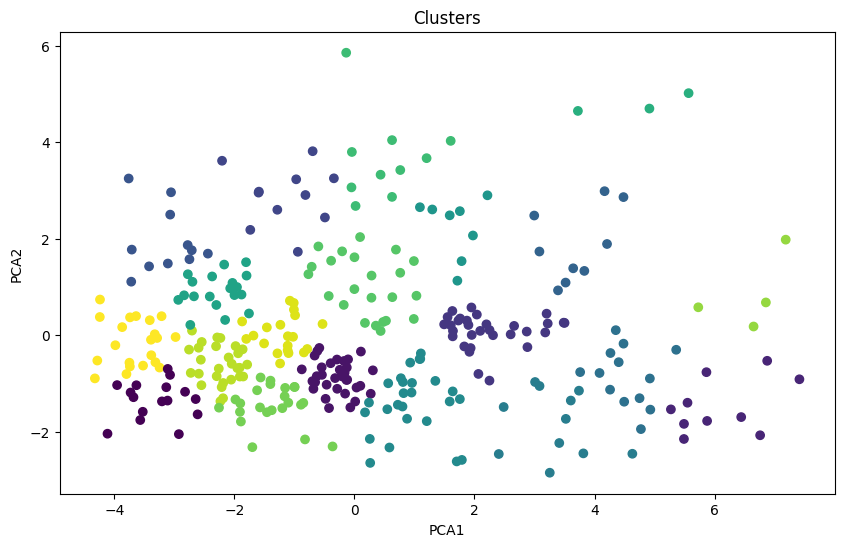

In [ ]:
# Para 2 clusters
# VERIFICAR
kmeans = KMeans(n_clusters=2,random_state=42)
labels2 = kmeans.fit_predict(pca_values)

plt.figure(figsize=(10,6))
plt.scatter(pca_values['PCA1'],pca_values['PCA2'],c=labels)
plt.title('Clusters')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

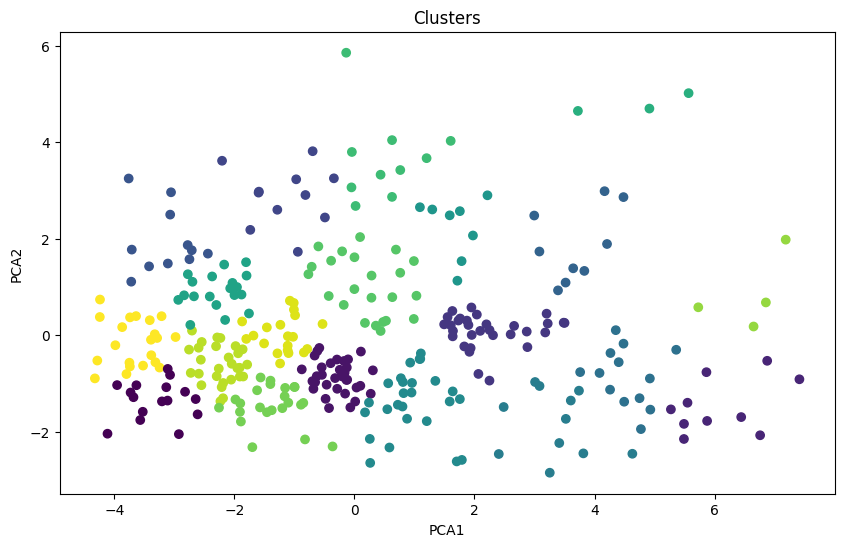

In [ ]:
## Para 6 clusters

kmeans = KMeans(n_clusters=7,random_state=42)
labels6 = kmeans.fit_predict(pca_values)

plt.figure(figsize=(10,6))
plt.scatter(pca_values['PCA1'],pca_values['PCA2'],c=labels)
plt.title('Clusters')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [ ]:
std_df['Cluster6'] = labels6
std_df['Cluster2'] = labels2
df_scout['Cluster6'] = labels6
df_scout['Cluster2'] = labels2

In [ ]:
def plot_scatter_subplots(pca_values, df, ncols=3, figsize_per_plot=5):
    cols = df.columns.tolist()
    nrows = math.ceil(len(cols) / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * figsize_per_plot, nrows * figsize_per_plot)
    )
    axes = axes.flatten()

    for i, col in enumerate(cols):
        axes[i].scatter(pca_values['PCA1'], pca_values['PCA2'], c=df[col], cmap='viridis')
        axes[i].set_title(col)
        axes[i].set_xlabel('PCA1')
        axes[i].set_ylabel('PCA2')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

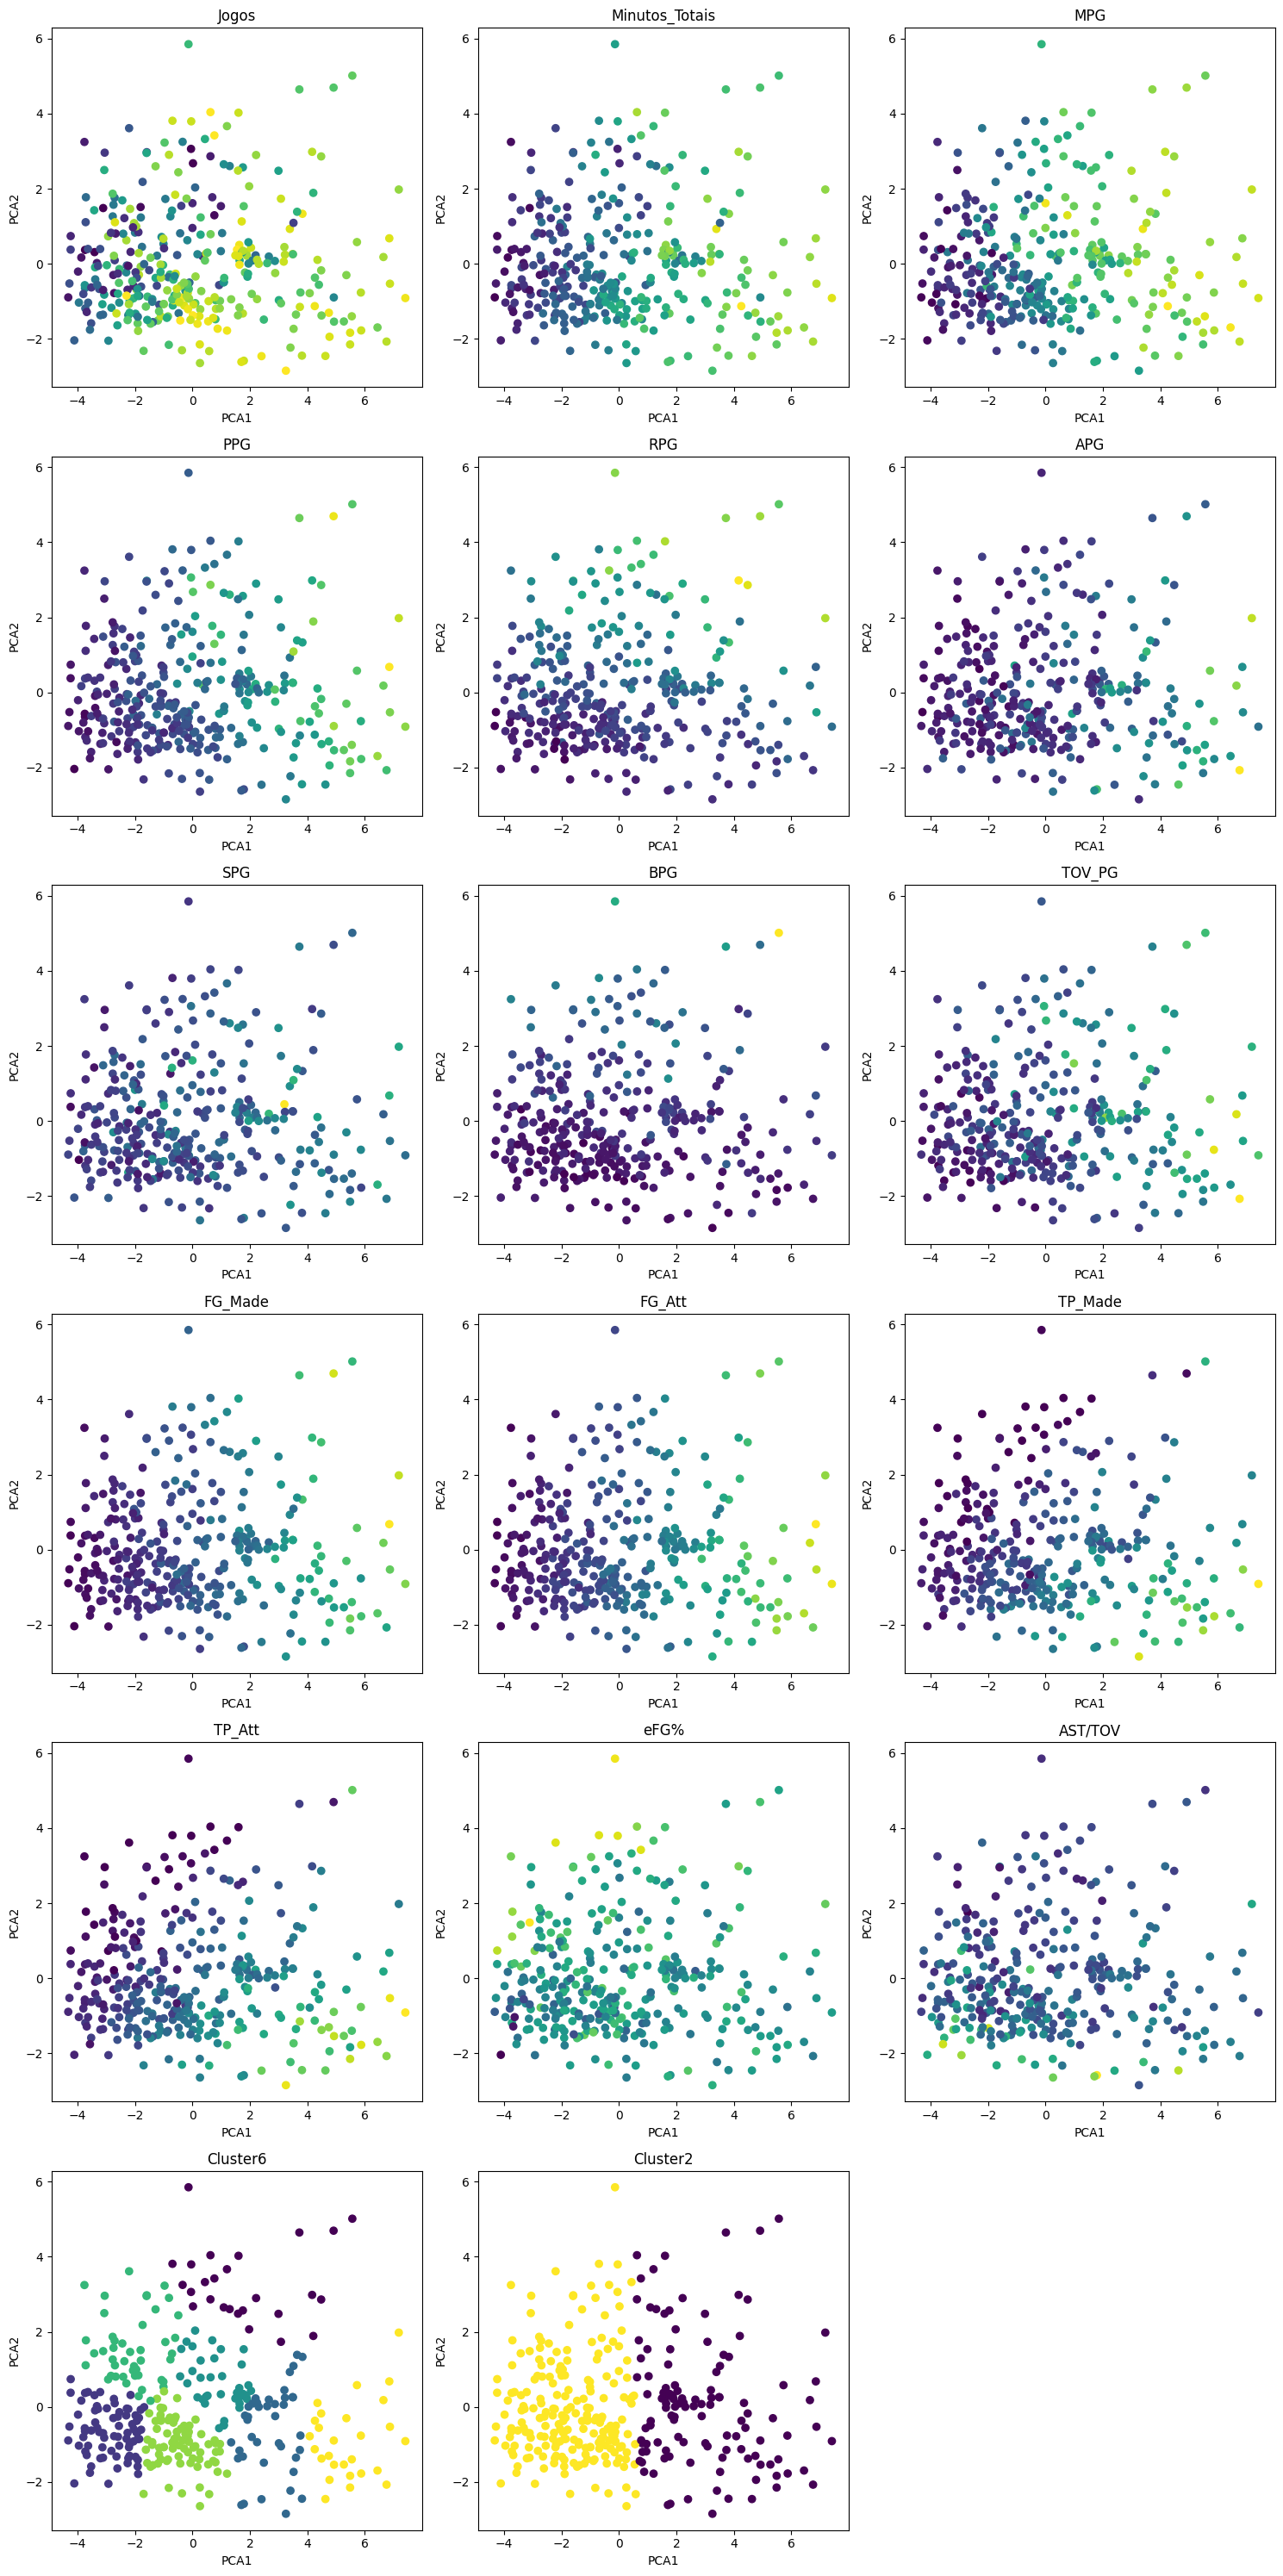

In [ ]:
plot_scatter_subplots(pca_values,std_df)

In [ ]:
df_scout

,Player,Tm,Jogos,Minutos_Totais,MPG,PPG,RPG,APG,SPG,BPG,TOV_PG,FG_Made,FG_Att,TP_Made,TP_Att,eFG%,AST/TOV,Cluster6,Cluster2
0,A.J. Green,MIL,44,967.89,22.00,7.66,2.25,1.27,0.55,0.11,0.61,114,258,96,222,0.63,2.07,5,1
4,Aaron Gordon,DEN,30,799.98,26.67,12.33,4.73,3.07,0.47,0.27,1.33,130,255,34,84,0.58,2.30,5,1
6,Aaron Nesmith,IND,15,314.24,20.95,8.20,3.33,1.27,0.60,0.27,0.73,41,83,15,36,0.58,1.73,1,1
7,Aaron Wiggins,OKC,51,1087.46,21.32,10.14,3.57,1.57,0.73,0.24,0.82,205,414,68,188,0.58,1.90,5,1
11,Ajay Mitchell,OKC,35,576.92,16.48,6.43,1.97,1.69,0.69,0.09,0.80,86,172,22,53,0.56,2.11,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,Zaccharie Risacher,ATL,45,1070.30,23.78,11.20,3.47,1.18,0.78,0.47,1.11,189,448,58,190,0.49,1.06,5,1
576,Zach Edey,MEM,37,772.11,20.87,9.86,7.78,1.00,0.65,1.19,1.51,150,255,14,39,0.62,0.66,4,1
577,Zach LaVine,CHI,42,1432.05,34.10,23.98,4.81,4.50,0.93,0.24,2.88,363,710,136,305,0.61,1.56,6,0
580,Ziaire Williams,BRK,38,896.61,23.60,9.39,4.79,1.42,1.00,0.42,1.05,120,300,49,151,0.48,1.35,5,1


In [ ]:
std_df['Cluster6']== 0

,Cluster6
0,False
1,False
2,False
3,False
4,False
...,...
325,False
326,False
327,False
328,False


In [ ]:
df_scout.reset_index(inplace=True)

In [ ]:
df_scout[df_scout['Player'] == 'LeBron James']

,index,Player,Tm,Jogos,Minutos_Totais,MPG,PPG,RPG,APG,SPG,BPG,TOV_PG,FG_Made,FG_Att,TP_Made,TP_Att,eFG%,AST/TOV,Cluster6,Cluster2
213,365,LeBron James,LAL,46,1594.86,34.67,24.46,7.78,9.04,0.87,0.52,3.78,432,838,100,256,0.58,2.39,6,0


In [ ]:
df_scout[std_df['Cluster6']== 6]

,index,Player,Tm,Jogos,Minutos_Totais,MPG,PPG,RPG,APG,SPG,BPG,TOV_PG,FG_Made,FG_Att,TP_Made,TP_Att,eFG%,AST/TOV,Cluster6,Cluster2
20,32,Anthony Edwards,MIN,51,1873.16,36.73,27.22,5.78,4.53,1.14,0.69,3.45,466,1045,212,504,0.55,1.31,6,0
42,69,Cade Cunningham,DET,47,1676.87,35.68,25.60,6.30,9.45,0.98,0.74,4.43,450,994,107,302,0.51,2.13,6,0
65,114,Damian Lillard,MIL,43,1558.24,36.24,25.00,4.65,7.42,1.16,0.21,2.84,330,740,147,387,0.55,2.61,6,0
68,123,Darius Garland,CLE,50,1517.10,30.34,21.86,2.56,6.72,1.12,0.20,2.52,391,782,151,348,0.60,2.67,6,0
71,129,De'Aaron Fox,SAC,45,1663.08,36.96,24.98,5.00,6.13,1.47,0.44,2.96,414,883,92,286,0.52,2.08,6,0
86,148,Devin Booker,PHO,46,1710.35,37.18,26.41,4.02,6.70,1.09,0.26,2.70,397,875,122,358,0.52,2.48,6,0
91,156,Donovan Mitchell,CLE,49,1534.00,31.31,24.02,4.35,4.73,1.43,0.20,2.00,414,918,180,457,0.55,2.37,6,0
134,234,Jalen Brunson,NYK,50,1763.69,35.27,26.08,2.90,7.52,0.96,0.08,2.42,451,922,116,292,0.55,3.11,6,0
136,236,Jalen Green,HOU,51,1693.23,33.20,21.45,4.35,2.92,0.88,0.31,2.53,384,899,145,414,0.51,1.16,6,0
140,242,Jalen Williams,OKC,48,1568.72,32.68,21.02,5.48,5.08,1.77,0.77,2.23,390,824,81,235,0.52,2.28,6,0


##Extra - Ideias

Os testes abaixo apresentados, foram baseados em outras analises e considerações devido aos altos indices de qualidades percebidos nos perfis dos jogadores.

In [ ]:
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

df_ml = df_scout.copy()

if '3PM_PG' not in df_ml.columns:
    df_ml['3PM_PG'] = (df_ml['TP_Made'] / df_ml['Jogos']).round(2)

features = ['PPG', 'RPG', 'APG', 'SPG', 'BPG', 'eFG%', 'AST/TOV', '3PM_PG']
X_scaled = StandardScaler().fit_transform(df_ml[features])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(X_scaled)

nomes_clusters = {
    0: '0: Armadores Seguros',
    1: '1: Donos do Garrafão',
    2: '2: Especialistas / Rotação',
    3: '3: Superstars'
}
df_ml['Nome_Cluster'] = df_ml['Cluster'].map(nomes_clusters)


features_radar = ['PPG', 'RPG', 'APG', 'SPG', 'BPG', 'eFG%', '3PM_PG']

medias_clusters = df_ml.groupby('Nome_Cluster')[features_radar].mean()

scaler_radar = MinMaxScaler()
medias_normalizadas = pd.DataFrame(
    scaler_radar.fit_transform(medias_clusters),
    columns=features_radar,
    index=medias_clusters.index
)

categorias = features_radar + [features_radar[0]]

fig = go.Figure()

cores = ['#EF553B', '#00CC96', '#AB63FA', '#FFA15A']

for i, nome_cluster in enumerate(medias_normalizadas.index):
    valores = medias_normalizadas.loc[nome_cluster].tolist()
    valores += [valores[0]]

    fig.add_trace(go.Scatterpolar(
        r=valores,
        theta=categorias,
        fill='toself',
        name=nome_cluster,
        line=dict(color=cores[i]),
        opacity=0.7
    ))

texto_dicionario = (
    "<b>Dicionário de Scouting</b><br><br>"
    "<b>PPG:</b> Pontos por jogo<br>"
    "<b>RPG:</b> Rebotes por jogo<br>"
    "<b>APG:</b> Assistências por jogo<br>"
    "<b>SPG:</b> Roubos de bola por jogo<br>"
    "<b>BPG:</b> Tocos (Bloqueios)<br>"
    "<b>3PM_PG:</b> Bolas de 3 convertidas<br>"
    "<b>eFG%:</b> Aproveitamento efetivo"
)

fig.add_annotation(
    x=1.1, y=-0.10,
    xref="paper", yref="paper",
    xanchor="left",
    yanchor="bottom",
    text=texto_dicionario,
    showarrow=False,
    align="left",
    font=dict(size=12, color="white"),
    bgcolor="rgba(40, 40, 40, 0.8)",
    bordercolor="gray",
    borderwidth=1,
    borderpad=12
)

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            showticklabels=False
        )
    ),
    showlegend=True,
    legend=dict(
        x=1.15, y=1.0,
        bgcolor="rgba(0,0,0,0)"
    ),
    title=dict(
        text="Perfil Estatístico dos Arquétipos da NBA",
        font=dict(size=20)
    ),
    margin=dict(l=80, r=250, t=80, b=100),
    width=950,
    height=600,
    template="plotly_dark"
)

fig.show()

In [ ]:
colunas_tabela = ['Player', 'Tm', 'PPG', 'RPG', 'APG', 'SPG', 'BPG', 'eFG%', '3PM_PG']


def exibir_top10_arquetipo(df, nome_cluster, coluna_ordenacao, cor_mapa):
    print(f"\n{'='*70}")
    print(f" TOP 10 - {nome_cluster.upper()} (Ordenado por {coluna_ordenacao})")
    print(f"{'='*70}")

    top10 = df[df['Nome_Cluster'] == nome_cluster].sort_values(by=coluna_ordenacao, ascending=False).head(10)
    top10 = top10[colunas_tabela]

    tabela_estilizada = top10.style.background_gradient(
        cmap=cor_mapa,
        subset=['PPG', 'RPG', 'APG', 'SPG', 'BPG', 'eFG%', '3PM_PG']
    ).format({
        'eFG%': '{:.1%}',
        'PPG': '{:.1f}', 'RPG': '{:.1f}', 'APG': '{:.1f}',
        'SPG': '{:.1f}', 'BPG': '{:.1f}', '3PM_PG': '{:.1f}'
    }).hide(axis="index")

    display(tabela_estilizada)


# 1. Superstars (Ordenado por Pontos - Paleta Vermelho/Laranja)
exibir_top10_arquetipo(df_ml, '3: Superstars', 'PPG', 'OrRd')

# 2. Donos do Garrafão (Ordenado por Rebotes - Paleta Azul)
exibir_top10_arquetipo(df_ml, '1: Donos do Garrafão', 'RPG', 'Blues')

# 3. Armadores Seguros (Ordenado por Assistências - Paleta Verde)
exibir_top10_arquetipo(df_ml, '0: Armadores Seguros', 'APG', 'Greens')

# 4. Especialistas / Rotação (Ordenado por Bolas de 3 - Paleta Roxa)
exibir_top10_arquetipo(df_ml, '2: Especialistas / Rotação', '3PM_PG', 'Purples')


 TOP 10 - 3: SUPERSTARS (Ordenado por PPG)


Player,Tm,PPG,RPG,APG,SPG,BPG,eFG%,3PM_PG
Shai Gilgeous-Alexander,OKC,32.4,5.2,5.9,1.9,1.0,58.0%,2.0
Nikola Jokić,DEN,29.7,12.7,10.3,1.8,0.7,63.0%,2.1
Luka Dončić,DAL,28.1,8.3,7.8,2.0,0.4,54.0%,3.4
LaMelo Ball,CHO,28.0,5.2,7.4,1.3,0.3,50.0%,4.1
Tyrese Maxey,PHI,27.8,3.4,6.2,1.9,0.4,52.0%,3.3
Anthony Edwards,MIN,27.2,5.8,4.5,1.1,0.7,55.0%,4.2
Kevin Durant,PHO,26.9,6.1,4.2,0.8,1.3,59.0%,2.4
Jayson Tatum,BOS,26.6,8.7,5.7,1.2,0.5,54.0%,3.5
Devin Booker,PHO,26.4,4.0,6.7,1.1,0.3,52.0%,2.6
Jalen Brunson,NYK,26.1,2.9,7.5,1.0,0.1,55.0%,2.3



 TOP 10 - 1: DONOS DO GARRAFÃO (Ordenado por RPG)


Player,Tm,PPG,RPG,APG,SPG,BPG,eFG%,3PM_PG
Domantas Sabonis,SAC,20.4,14.3,6.3,0.6,0.4,64.0%,1.1
Karl-Anthony Towns,NYK,24.3,13.6,3.3,1.0,0.8,59.0%,2.0
Ivica Zubac,LAC,15.2,12.7,2.5,0.7,1.1,61.0%,0.0
Giannis Antetokounmpo,MIL,31.6,12.3,6.0,0.8,1.4,61.0%,0.1
Isaiah Hartenstein,OKC,11.5,12.0,4.1,0.8,1.1,56.0%,0.0
Walker Kessler,UTA,11.2,11.9,1.6,0.6,2.4,71.0%,0.1
Anthony Davis,LAL,25.7,11.9,3.4,1.3,2.1,55.0%,0.7
Victor Wembanyama,SAS,24.4,10.9,3.6,1.1,3.9,56.0%,3.1
Alperen Sengun,HOU,18.8,10.5,5.0,1.2,0.9,50.0%,0.3
Nikola Vučević,CHI,19.5,10.4,3.5,0.9,0.7,61.0%,1.8



 TOP 10 - 0: ARMADORES SEGUROS (Ordenado por APG)


Player,Tm,PPG,RPG,APG,SPG,BPG,eFG%,3PM_PG
Chris Paul,SAS,9.3,4.1,8.2,1.3,0.2,54.0%,1.8
Ben Simmons,BRK,6.2,5.2,6.9,0.8,0.5,55.0%,0.0
Tyus Jones,PHO,11.0,2.4,5.8,0.9,0.1,58.0%,2.1
Isaiah Collier,UTA,6.5,2.9,5.5,0.8,0.2,44.0%,0.5
Draymond Green,GSW,8.4,6.0,5.5,1.1,1.1,51.0%,1.3
Scoot Henderson,POR,12.6,3.1,5.4,1.2,0.3,51.0%,1.5
Andrew Nembhard,IND,10.8,3.4,5.1,1.3,0.1,52.0%,0.8
Scotty Pippen,MEM,10.8,3.5,5.1,1.1,0.4,54.0%,1.1
Jimmy Butler,MIA,17.0,5.2,4.8,1.1,0.4,56.0%,0.5
D'Angelo Russell,LAL,12.4,2.8,4.7,0.8,0.1,50.0%,1.9



 TOP 10 - 2: ESPECIALISTAS / ROTAÇÃO (Ordenado por 3PM_PG)


Player,Tm,PPG,RPG,APG,SPG,BPG,eFG%,3PM_PG
Klay Thompson,DAL,13.7,3.4,2.0,0.8,0.4,55.0%,3.0
Lauri Markkanen,UTA,19.3,6.2,1.7,0.7,0.4,53.0%,3.0
Michael Porter Jr.,DEN,19.4,6.5,1.4,0.5,0.6,63.0%,2.9
De'Andre Hunter,ATL,19.0,3.9,1.5,0.8,0.1,56.0%,2.6
Buddy Hield,GSW,11.7,3.3,1.7,0.8,0.3,54.0%,2.6
Grayson Allen,PHO,11.1,3.5,2.0,0.9,0.3,61.0%,2.6
Duncan Robinson,MIA,10.8,2.3,2.6,0.6,0.1,55.0%,2.5
Tim Hardaway Jr.,DET,12.2,2.7,1.6,0.6,0.2,54.0%,2.5
Royce O'Neale,PHO,9.4,5.1,2.1,1.0,0.6,58.0%,2.4
Dillon Brooks,HOU,13.6,3.8,1.5,0.8,0.2,52.0%,2.4


#DBSCAN

Baseado em nossa analise, os ruidos constatados, na verdade se referem alguns dos melhores jogadores da temporada, sendo assim considerados como outiliers, não por definição mediana, mas sim devido as melhores pontuações e demais marcadores encontrados nos perfis.


Número de clusters encontrados: 1
Pontos classificados como ruído: 4


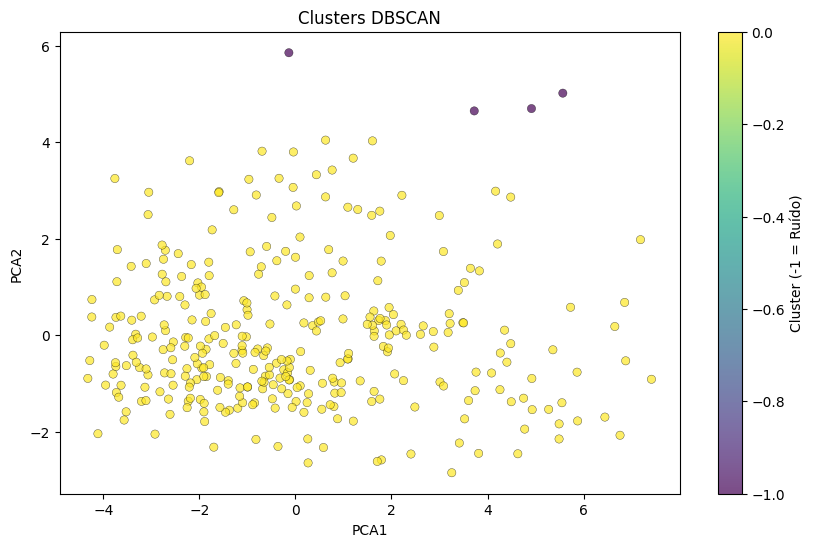

,index,Player,Tm,Jogos,Minutos_Totais,MPG,PPG,RPG,APG,SPG,...,TOV_PG,FG_Made,FG_Att,TP_Made,TP_Att,eFG%,AST/TOV,Cluster6,Cluster2,Cluster_DBSCAN
19,31,Anthony Davis,LAL,42,1439.52,34.27,25.74,11.86,3.36,1.29,...,2.21,400,757,28,94,0.55,1.52,0,0,-1
109,189,Giannis Antetokounmpo,MIL,42,1467.71,34.95,31.62,12.33,5.98,0.79,...,3.45,531,876,6,32,0.61,1.73,0,0,-1
319,559,Victor Wembanyama,SAS,43,1421.91,33.07,24.42,10.91,3.63,1.07,...,3.30,384,809,135,383,0.56,1.10,0,0,-1
321,564,Walker Kessler,UTA,40,1208.70,30.22,11.18,11.90,1.55,0.57,...,1.50,193,273,2,7,0.71,1.03,0,1,-1


In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(pca_values)

n_clusters = len(set(labels_dbscan) - {-1})
n_noise = (labels_dbscan == -1).sum()

print(f'Número de clusters encontrados: {n_clusters}')
print(f'Pontos classificados como ruído: {n_noise}')
if n_clusters >= 2:
    print(f'Silhouette Score: {silhouette_score(pca_values, labels_dbscan):.4f}')

plt.figure(figsize=(10,6))
scatter = plt.scatter(pca_values['PCA1'], pca_values['PCA2'],
                      c=labels_dbscan, cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label='Cluster (-1 = Ruído)')
plt.title('Clusters DBSCAN')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()


std_df['Cluster_DBSCAN'] = labels_dbscan
df_scout['Cluster_DBSCAN'] = labels_dbscan
df_scout[std_df['Cluster_DBSCAN'] == -1]